In [44]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import root_scalar

In [45]:
# 1. Physics of Vibrations // part a

Frequencies: [3.16227766 4.47213595]


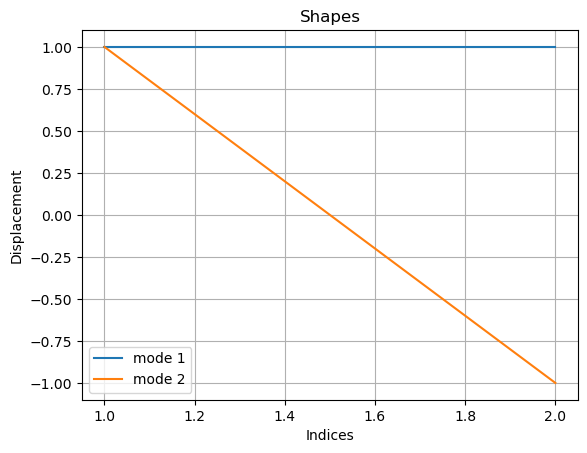

In [46]:
# set up the system
m1, m2 = 1.0, 1.0              # mass in kg
k1, k2, k3 = 10.0, 5.0, 10.0   # spring constants in N/m

# build the matrix
K = np.array([
    [(k1 + k2)/m1, -k2/m1],
    [-k2/m2, (k2 + k3)/m2]
])

# eigenvalues and eigenvectors
# evals: The eigenvalues (omega squared)
# evecs: The eigenvectors (The 'Shape' of the motion)
evals, evecs = np.linalg.eig(K)

# sort the eignevalues / eigenvectors
idx = np.argsort(evals)
evals = evals[idx]        # eigen values
evecs = evecs[:, idx]     # eigen vectors
omega = np.sqrt(evals)   # square root of the eigen values
evecs = evecs / np.max(np.abs(evecs), axis=0)

# plotting
print("Frequencies:", omega)
plt.figure()
plt.plot([1,2], evecs[:,0], label='mode 1')
plt.plot([1,2], evecs[:,1], label='mode 2')
plt.title("Shapes")
plt.xlabel("Indices")
plt.ylabel("Displacement")
plt.legend()
plt.grid()

In [47]:
#Questions
print("Q: What happens if the masses are different?")
print("If the masses are different, the heavier mass should move less than the light mass.")
print("Q: Predict what you expect, and then explain what you see.")
print("Prediction: The system will no longer be symmetric.")
print("Observation: The amplitudes of the 2 masses are not longer equal, giving the heavier mass a smaller displacement.")
print("Q: What happens if k2 is very small?")
print("The motion looks like 2 separate oscillators.")
print("Q: What happens if you double all the spring constants?")
print("The frequencies increase compared to the starting system.")

Q: What happens if the masses are different?
If the masses are different, the heavier mass should move less than the light mass.
Q: Predict what you expect, and then explain what you see.
Prediction: The system will no longer be symmetric.
Observation: The amplitudes of the 2 masses are not longer equal, giving the heavier mass a smaller displacement.
Q: What happens if k2 is very small?
The motion looks like 2 separate oscillators.
Q: What happens if you double all the spring constants?
The frequencies increase compared to the starting system.


In [48]:
# 1. Physics of Vibrations // part b

Frequencies: [1.52338081e-08 9.89378428e-01 1.95439508e+00 2.87128803e+00
 3.71748034e+00 4.47213595e+00 5.11667274e+00 5.63522005e+00
 6.01500955e+00 6.24668955e+00]


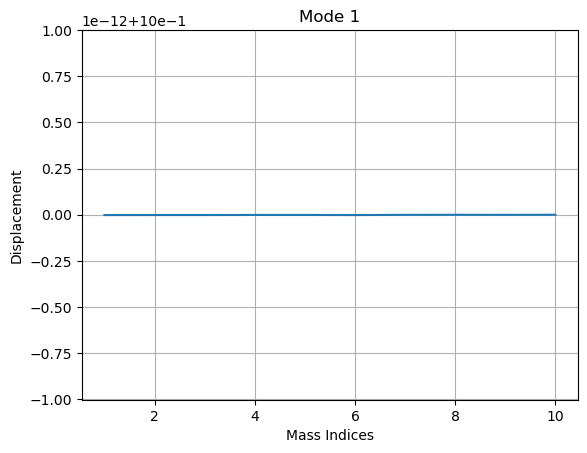

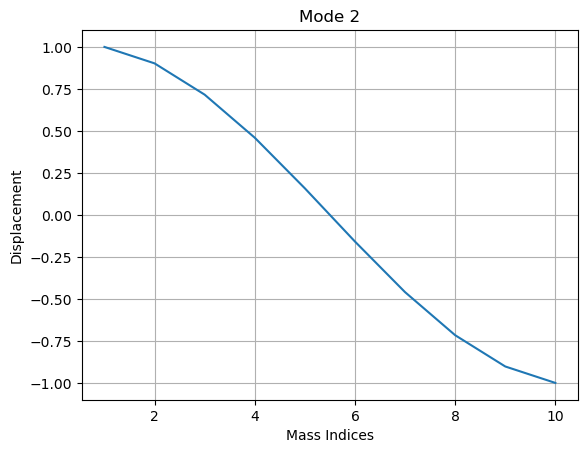

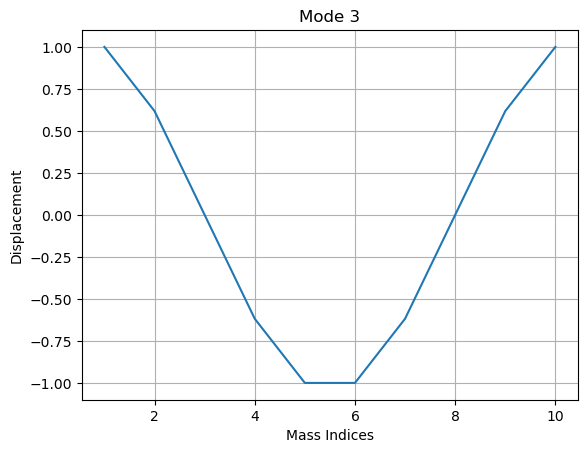

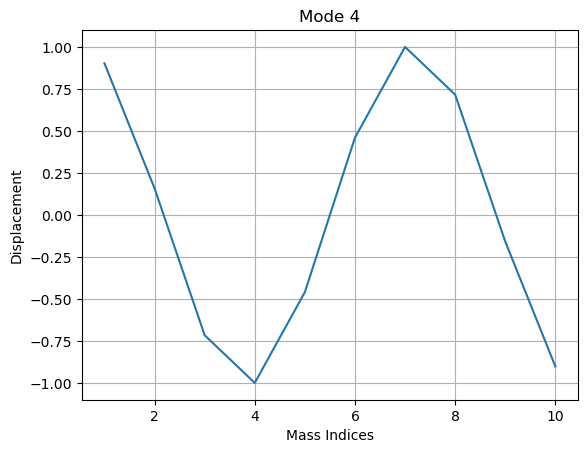

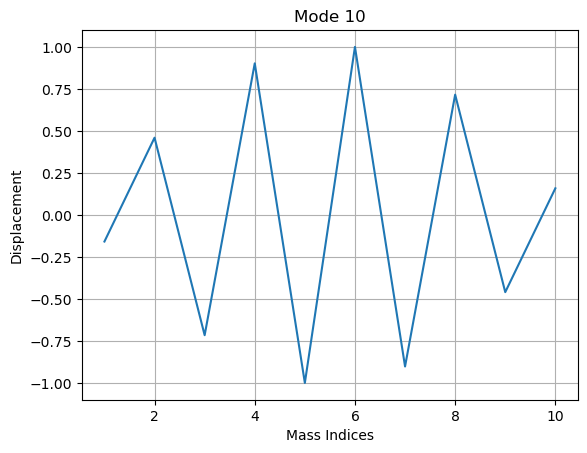

In [65]:
# set up the system
N = 10           # number of objects with mass
m = 1.0         # mass in kg
k1 = 10.0        # spring constants in N/m

# build the matrix
K = np.zeros((N,N))
for i in range (N):
    # left neighbor
    if i > 0:
        K[i, i-1] = (-k1/m)
    # right neighbor
    if i < N-1:
        K[i,i+1] = (-k1/m)
    # diagonal neighbors
    connection = 0
    if i > 0:
        connection += 1
    if i < N-1:
        connection += 1
    K[i,i] = (connection*k1)/m

# eigenvalues and eigenvectors
evals, evecs = np.linalg.eig(K)

# sort the eignevalues / eigenvectors
idx = np.argsort(evals)
evals = evals[idx]        # eigen values
evecs = evecs[:, idx]     # eigen vectors
omega = np.sqrt(evals)   # square root of the eigen values
evecs = evecs / np.max(np.abs(evecs), axis=0)

# plotting first 4 modes
print("Frequencies:", omega)
for i in range (4):
    plt.figure()
    plt.plot(range(1,N+1), evecs[:,i])
    plt.title(f"Mode {i+1}")
    plt.xlabel("Mass Indices")
    plt.ylabel("Displacement")
    plt.grid()

#plotting the 10th node
plt.figure()
plt.plot(range(1,N+1), evecs[:,9])
plt.title("Mode 10")
plt.xlabel("Mass Indices")
plt.ylabel("Displacement")
plt.grid()

In [50]:
# Questions
print("Q: How many zero crossings (nodes) are there for the first four modes? How many do you expect for the 10th mode?")
print("mode 1: 0 nodes, mode 2: 1 node, mode 3: 2 nodes, mode 4: 3 nodes")
print("Q: Look at the 10th mode. How do the masses move relative to each other?")
print("The nodes move at N-1 relative to each other.")

Q: How many zero crossings (nodes) are there for the first four modes? How many do you expect for the 10th mode?
mode 1: 0 nodes, mode 2: 1 node, mode 3: 2 nodes, mode 4: 3 nodes
Q: Look at the 10th mode. How do the masses move relative to each other?
The nodes move at N-1 relative to each other.


In [51]:
# 1. Physics of Vibrations // part c

In [52]:
print(evecs.shape)
# first Mode or first Mass?
print(evecs[0])
# displacement of Mass 3 during Mode 5
print(evecs[2,4])

(10, 10)
[ 1.          1.          1.          0.90211303  0.80901699 -1.
  0.61803399 -0.45964955 -0.30901699 -0.15838444]
-1.0


In [53]:
# Questions
print("Q: Does evecs[0] give you the first Mode, or the first Mass?")
print("It gives you the first mass.")
print("Q: If you wanted to find the displacement of Mass #3 during Mode #5, how would you index the evecs array?")
print("It would work by using evecs[2,4] because python uses zero based indexing.")

Q: Does evecs[0] give you the first Mode, or the first Mass?
It gives you the first mass.
Q: If you wanted to find the displacement of Mass #3 during Mode #5, how would you index the evecs array?
It would work by using evecs[2,4] because python uses zero based indexing.


In [54]:
# 2. Static Systems: Solving for the Unknown // part a

In [55]:
# create an array
A = np.array([
    [10,-2,0],
    [-2,8,-4],
    [0,-4,6]
])
b = np.array([12,0,-5])

# create a system
I = np.linalg.solve(A,b)
print("Current:")
print("I1 =",I[0])
print("I2 =",I[1])
print("I3 =",I[2])

Current:
I1 = 1.162162162162162
I2 = -0.18918918918918914
I3 = -0.9594594594594594


In [56]:
# 2. Static Systems: Solving for the Unknown // part b

In [57]:
# define the constants
theta1 = np.radians(30)
theta2 = np.radians(45)
W = 1.0

# create an array
A = np.array([
    [-np.cos(theta1), np.cos(theta2)],
    [np.sin(theta1), np.sin(theta2)],
])
b = np.array([0,W])

# create a system
T = np.linalg.solve(A,b)
print("Tension: ")
print("T1 =", T[0])
print("T2 =", T[1])

Tension: 
T1 = 0.7320508075688774
T2 = 0.8965754721680537


In [58]:
# 3. SymPy: Duffing Oscillator

Symbolic Force: 
-1.0*alpha*x - 1.0*beta*x**3


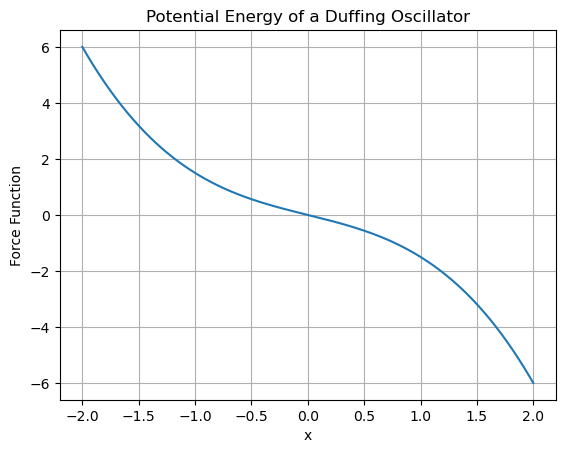

In [59]:
# define constants
x = sp.Symbol('x')
alpha, beta = sp.symbols('alpha beta')
V = (1/2)*alpha*x**2 + (1/4)*beta*x**4   # potential

# compute the force
force_expr = -sp.diff(V,x)
print("Symbolic Force: ")
print(force_expr)
alpha_val = 1
beta_val = 0.5
force_with_constants = force_expr.subs({alpha: alpha_val, beta: beta_val})
force_func = sp.lambdify(x, force_with_constants, 'numpy')

# plotting the figure
x_val = np.linspace(-2,2,400)
F_val = force_func(x_val)
plt.figure()
plt.plot(x_val,F_val)
plt.title("Potential Energy of a Duffing Oscillator")
plt.xlabel("x")
plt.ylabel("Force Function")
plt.grid()

In [60]:
# 4. SymPy: Solving the Damped Oscillator (ODEs)

In [61]:
# define constants
t = sp.Symbol('t')
gamma, omega0 = sp.symbols('gamma omega0')
x = sp.Function('x')

# build the ordinary differential equations and find general solution
ode = sp.Eq(
    x(t).diff(t,2) + gamma*x(t).diff(t) + omega0**2*x(t), 0)
solution = sp.dsolve(ode)
print("General Solution: ")
print(solution)

#overdamping
overdamped_solution = solution.subs({gamma: 5, omega0: 2})
print("Overdamped Solution: ")
print(overdamped_solution)

General Solution: 
Eq(x(t), C1*exp(t*(-gamma + sqrt(gamma**2 - 4*omega0**2))/2) + C2*exp(-t*(gamma + sqrt(gamma**2 - 4*omega0**2))/2))
Overdamped Solution: 
Eq(x(t), C1*exp(-t) + C2*exp(-4*t))


In [62]:
# 5. Quantum: The Finite Square Well

Ground State Energy: 
1.407214724770161


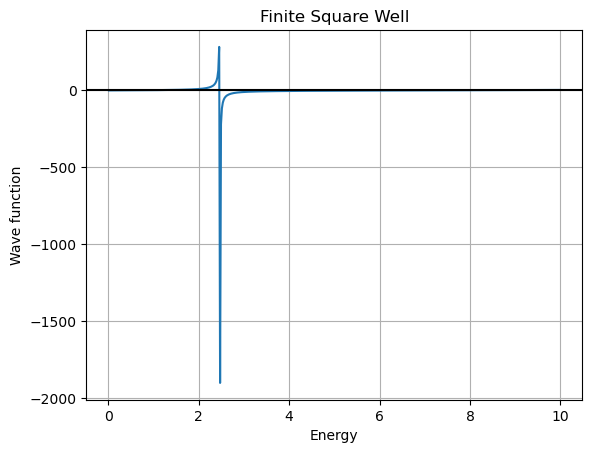

In [64]:
# define constants
E = sp.Symbol('E')
V0 = 10

# define the root function
lhs = sp.sqrt(E)* sp.tan(sp.sqrt(E))
rhs = sp.sqrt(V0-E)
f_expr = lhs - rhs
f_func = sp.lambdify(E,f_expr,'numpy')
E_vals = np.linspace(0.01, V0-0.01, 500)
f_vals = f_func(E_vals)

# plotting the figure
plt.figure()
plt.plot(E_vals,f_vals)
plt.axhline(0, color='black')
plt.title("Finite Square Well")
plt.xlabel("Energy")
plt.ylabel("Wave function")
plt.grid()

# find the ground state energy
root = root_scalar(f_func, bracket=[0.1,2])
print("Ground State Energy: ")
print(root.root)